In [1]:
#All libraries needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import lime
import lime.lime_tabular
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

shap.initjs()
print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
#Loadind the dataset
df_raw = pd.read_excel(r"D:\Purely4.2\PROJECT_FILES\AutoInsuranceClaimsData.xlsx")
df_use = df_raw.copy()

In [3]:
print("Shape:", df_use.shape)

Shape: (10000, 40)


In [4]:
print("\nColumn names:", df_use.columns.tolist())


Column names: ['months_as_customer', 'age', 'policy_number', 'policy_bind_date', 'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'capital-gains', 'capital-loss', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'property_damage', 'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make', 'auto_model', 'auto_year', 'fraud_reported', '_c39']


In [5]:
df_use.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   months_as_customer           9000 non-null   float64       
 1   age                          9000 non-null   float64       
 2   policy_number                9000 non-null   float64       
 3   policy_bind_date             9000 non-null   datetime64[ns]
 4   policy_state                 9000 non-null   object        
 5   policy_csl                   9000 non-null   object        
 6   policy_deductable            9000 non-null   float64       
 7   policy_annual_premium        9000 non-null   float64       
 8   umbrella_limit               9000 non-null   float64       
 9   insured_zip                  9000 non-null   float64       
 10  insured_sex                  9000 non-null   object        
 11  insured_education_level      9000 non-null

In [6]:
# Statistical summary
df_use.describe()

,months_as_customer,age,policy_number,policy_bind_date,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,...,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,9000.000000,9000.000000,9.000000e+03,9000,9000.000000,9000.000000,9.000000e+03,9000.000000,9000.000000,9000.000000,...,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,0.0
mean,203.967444,38.952333,5.462581e+05,2009-01-01 21:54:46.768676352,1135.719889,1256.355045,1.100888e+06,501228.654222,25125.665889,-26790.306556,...,11.642556,1.839000,0.992000,1.487000,52757.253667,7433.824444,7398.284111,37928.123222,2004.919333,NaN
min,0.000000,19.000000,9.850400e+04,1993-06-21 19:49:33.537000,484.000000,427.503185,-1.021687e+06,419228.000000,0.000000,-112325.000000,...,0.000000,1.000000,0.000000,0.000000,98.000000,0.000000,0.000000,69.000000,1920.000000,NaN
25%,115.000000,32.000000,3.360755e+05,2001-03-28 08:52:10.152749952,503.000000,1089.215615,0.000000e+00,448351.750000,0.000000,-51460.000000,...,6.000000,1.000000,0.000000,1.000000,41817.250000,4302.750000,4460.500000,30205.500000,1991.000000,NaN
50%,200.000000,38.000000,5.326865e+05,2009-01-01 21:54:46.768499968,999.000000,1256.866541,0.000000e+00,466476.500000,0.000000,-23189.000000,...,12.000000,1.000000,1.000000,1.000000,58108.000000,6777.000000,6751.500000,42136.500000,2005.000000,NaN
75%,277.000000,45.000000,7.616242e+05,2016-10-08 10:57:23.384249856,1982.000000,1416.862979,0.000000e+00,601260.750000,50960.500000,0.000000,...,17.000000,3.000000,2.000000,2.000000,70656.250000,11264.500000,10894.000000,50806.250000,2019.000000,NaN
max,487.000000,65.000000,1.019466e+06,2024-07-15 00:00:00,2074.000000,2079.820328,1.014307e+07,639461.000000,101957.000000,0.000000,...,24.000000,4.000000,2.000000,3.000000,118268.000000,21575.000000,23866.000000,80637.000000,2087.000000,NaN
std,115.128240,9.147934,2.569948e+05,NaN,611.533245,244.101854,2.296253e+06,71866.450427,27862.468621,28095.678471,...,6.946601,1.018427,0.819763,1.110841,26390.546842,4880.489722,4823.624777,18878.923565,21.228665,NaN


In [7]:
# ── Check how many fraud vs legitimate claims exist ──
print("Class distribution (raw counts):")
print(df_use['fraud_reported'].value_counts())

print("\nClass proportions:")
print(df_use['fraud_reported'].value_counts(normalize=True).round(3))

Class distribution (raw counts):
fraud_reported
N    6777
Y    2223
Name: count, dtype: int64

Class proportions:
fraud_reported
N    0.753
Y    0.247
Name: proportion, dtype: float64


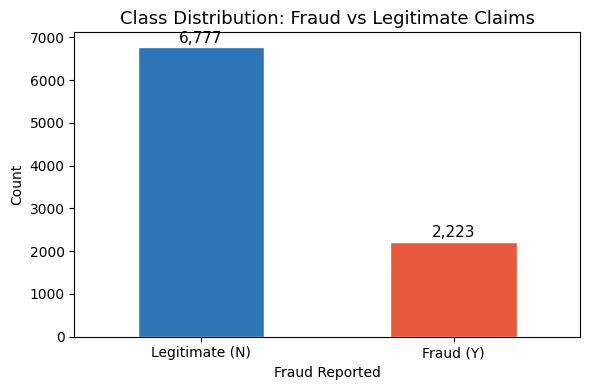

In [8]:
# Visualizing the imbalance
fig, ax = plt.subplots(figsize=(6, 4))

df_use['fraud_reported'].value_counts().plot(
    kind='bar',                 # Create a bar chart
    ax=ax,                      # Draw on the axis created above
    color=['#2E75B6', '#E8593C'],  # Set colours for each bar
    edgecolor='white',          # Add white border around bars
    width=0.5                   # Control bar thickness
)
# Title to the chart
ax.set_title(
    'Class Distribution: Fraud vs Legitimate Claims',
    fontsize=13
)
# Label x-axis
ax.set_xlabel('Fraud Reported')

# Label y-axis
ax.set_ylabel('Count')

# Rename x-axis categories with new labels: Legitimate (N), Fraud (Y)
ax.set_xticklabels(
    ['Legitimate (N)', 'Fraud (Y)'],
    rotation=0                  # Keep labels horizontal
)

# Add count values above each bar
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # Horizontal position (center)
        bar.get_height() + 30,              # Slightly above the bar
        f'{int(bar.get_height()):,}',       # Format with commas
        ha='center',                        # Center text horizontally
        va='bottom',                        # Align text above bar
        fontsize=11
    )
# Adjust spacing to avoid overlapping labels
plt.tight_layout()
# Save the chart as an image file
plt.savefig(
    'class_distribution.png',
    dpi=150                 # Image resolution
)

plt.show()

In [9]:
print("=== Blank/NaN values per column ===")
print(df_use.isna().sum()[df_use.isna().sum() > 0])

print("\n=== Literal '?' values per column ===")
print((df_use == '?').sum()[(df_use == '?').sum() > 0])

=== Blank/NaN values per column ===
months_as_customer              1000
age                             1000
policy_number                   1000
policy_bind_date                1000
policy_state                    1000
policy_csl                      1000
policy_deductable               1000
policy_annual_premium           1000
umbrella_limit                  1000
insured_zip                     1000
insured_sex                     1000
insured_education_level         1000
insured_occupation              1000
insured_hobbies                 1000
insured_relationship            1000
capital-gains                   1000
capital-loss                    1000
incident_date                   1000
incident_type                   1000
collision_type                  1000
incident_severity               1000
authorities_contacted           1819
incident_state                  1000
incident_city                   1000
incident_location               1000
incident_hour_of_the_day        1000
nu

In [10]:
#DATA PREPROCESSING
# Remove the completely empty column
df_use = df_use.drop(columns=['_c39'], errors='ignore')

In [11]:

# Clean and encode the target variable 
# Strip whitespace, uppercase, then map Y→1 and N→0
df_use['fraud_reported'] = (
    df_use['fraud_reported']
    .astype(str)
    .str.strip()
    .str.upper()
    .map({'Y': 1, 'N': 0})
)

In [12]:
# Convert literal "?" strings to true NaN, across ALL columns
import numpy as np

print("Columns containing '?' before fix:")
for col in df_use.select_dtypes(include='object').columns:
    q_count = (df_use[col] == '?').sum()
    if q_count > 0:
        print(f"  {col}: {q_count}")

df_use = df_use.replace('?', np.nan)

print("\nTotal '?' remaining after fix:", (df_use == '?').sum().sum())

Columns containing '?' before fix:
  collision_type: 1602
  property_damage: 3240
  police_report_available: 3087

Total '?' remaining after fix: 0


In [13]:
# Rows where fraud_reported was null (the 1000 missing rows) become 0
df_use['fraud_reported'] = df_use['fraud_reported'].fillna(0).astype(int)

In [14]:
# Extract useful features from date columns
# Tree models cannot use raw dates, extract year and month instead
df_use['policy_bind_date'] = pd.to_datetime(df_use['policy_bind_date'], errors='coerce')
df_use['incident_date']    = pd.to_datetime(df_use['incident_date'],    errors='coerce')

df_use['policy_year']    = df_use['policy_bind_date'].dt.year
df_use['policy_month']   = df_use['policy_bind_date'].dt.month
df_use['incident_year']  = df_use['incident_date'].dt.year
df_use['incident_month'] = df_use['incident_date'].dt.month

# Drop the original date columns
df_use = df_use.drop(columns=['policy_bind_date', 'incident_date'])

In [15]:
# Fill missing values
# Numerical columns filled with median
num_cols = df_use.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    if col != 'fraud_reported':
        df_use[col] = df_use[col].fillna(df_use[col].median())

# Categorical columns fill with "Unknown"
cat_cols = df_use.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_use[col] = df_use[col].fillna('Unknown')

In [16]:
# Remove high-cardinality and leakage columns
# incident_location has 1001 unique values so its too noisy for encoding
df_use = df_use.drop(columns=['incident_location'])

# These financial columns would only be known AFTER a claim is settled
leakage_cols = ['total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim']
df_use = df_use.drop(columns=leakage_cols)

print("Null values remaining:", df_use.isnull().sum().sum())
print("Final shape:", df_use.shape)
print("\nTarget distribution:")
print(df_use['fraud_reported'].value_counts())

Null values remaining: 0
Final shape: (10000, 36)

Target distribution:
fraud_reported
0    7777
1    2223
Name: count, dtype: int64


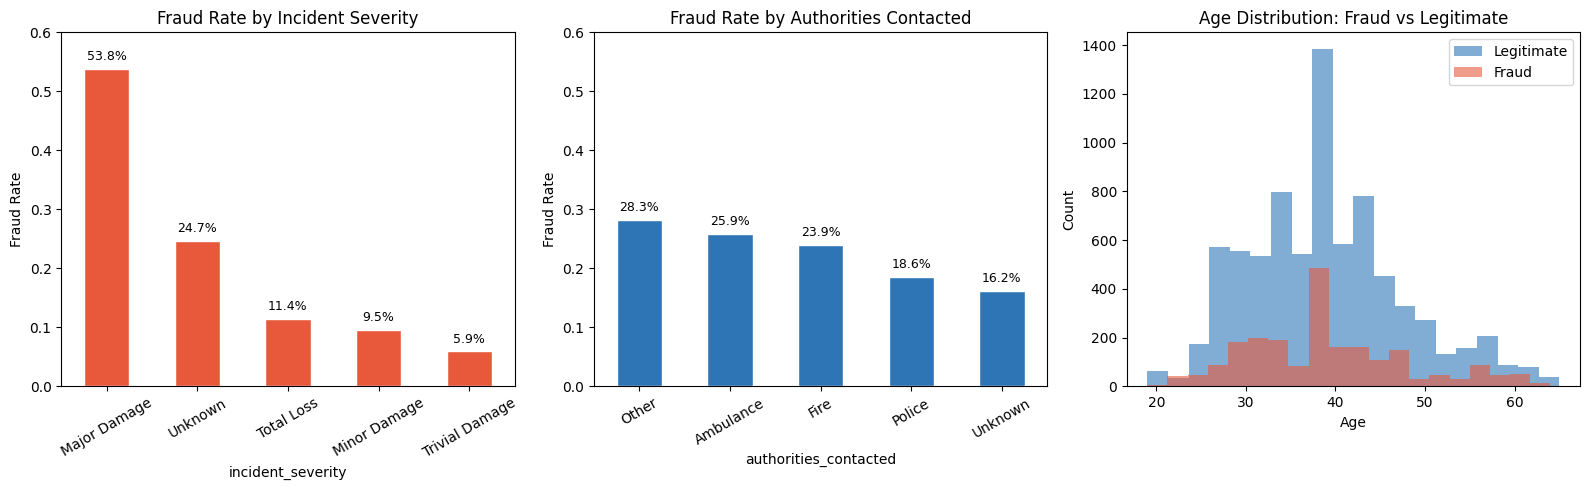


Top 10 numerical features correlated with fraud:
incident_year                  0.0971
policy_year                    0.0967
umbrella_limit                 0.0476
witnesses                      0.0402
number_of_vehicles_involved    0.0389
bodily_injuries                0.0297
policy_number                  0.0262
capital-gains                  0.0215
months_as_customer             0.0177
insured_zip                    0.0142
dtype: float64


In [17]:
#EDA VISUALIZATIONS
# Fraud rate by incident severity
# Which severity types have the most fraud?
sev_fraud = (
    df_use.groupby('incident_severity')['fraud_reported']
    .mean()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sev_fraud.plot(kind='bar', ax=axes[0], color='#E8593C', edgecolor='white')
axes[0].set_title('Fraud Rate by Incident Severity', fontsize=12)
axes[0].set_ylabel('Fraud Rate')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(0, 0.6)
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.1%}',
        ha='center', va='bottom', fontsize=9
    )

# Fraud rate by authorities contacted 
auth_fraud = (
    df_use.groupby('authorities_contacted')['fraud_reported']
    .mean()
    .sort_values(ascending=False)
)
auth_fraud.plot(kind='bar', ax=axes[1], color='#2E75B6', edgecolor='white')
axes[1].set_title('Fraud Rate by Authorities Contacted', fontsize=12)
axes[1].set_ylabel('Fraud Rate')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(0, 0.6)
for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.1%}',
        ha='center', va='bottom', fontsize=9
    )

# Age distribution: fraud vs legitimate
df_use[df_use['fraud_reported'] == 0]['age'].plot(
    kind='hist', ax=axes[2], alpha=0.6,
    bins=20, color='#2E75B6', label='Legitimate'
)
df_use[df_use['fraud_reported'] == 1]['age'].plot(
    kind='hist', ax=axes[2], alpha=0.6,
    bins=20, color='#E8593C', label='Fraud'
)
axes[2].set_title('Age Distribution: Fraud vs Legitimate', fontsize=12)
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_patterns.png', dpi=150)
plt.show()

# Correlation of numerical features with fraud
num_cols_clean = df_use.select_dtypes(include=['float64', 'int64']).columns
corr = (
    df_use[num_cols_clean]
    .corrwith(df_use['fraud_reported'])
    .abs()
    .sort_values(ascending=False)
    .drop('fraud_reported')
    .head(10)
)
print("\nTop 10 numerical features correlated with fraud:")
print(corr.round(4))

In [18]:
# Replace Unknown with NaN so get_dummies handles it cleanly
df_model = df_use.replace('Unknown', np.nan)

# One-hot encode all categorical columns 
# drop_first=True avoids multicollinearity
df_model = pd.get_dummies(df_model, drop_first=True)

# Separate features and target
X = df_model.drop('fraud_reported', axis=1)
y = df_model['fraud_reported']

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Feature matrix shape: (10000, 142)
Target distribution:
fraud_reported
0    7777
1    2223
Name: count, dtype: int64


In [19]:
# Train-test split
# stratify=y ensures both sets keep the same fraud/legitimate ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain set:", X_train.shape, "| Fraud in train:", y_train.sum())
print("Test set: ", X_test.shape,  "| Fraud in test: ", y_test.sum())


Train set: (8000, 142) | Fraud in train: 1778
Test set:  (2000, 142) | Fraud in test:  445


In [20]:
#Apply SMOTE to training set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nBefore SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_smote.value_counts().to_dict())
print("Test set (unchanged):", y_test.value_counts().to_dict())


Before SMOTE: {0: 6222, 1: 1778}
After SMOTE:  {0: 6222, 1: 6222}
Test set (unchanged): {0: 1555, 1: 445}


In [21]:
#BASE LINE LOGISTIC REGRESSION MODEL

lr_model = LogisticRegression(max_iter=2000, random_state=42)
lr_model.fit(X_train_smote, y_train_smote)
y_pred_lr = lr_model.predict(X_test)

print("=== LOGISTIC REGRESSION (BASELINE) ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Legitimate', 'Fraud']))

=== LOGISTIC REGRESSION (BASELINE) ===
Accuracy: 0.5595

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.80      0.58      0.67      1555
       Fraud       0.25      0.47      0.32       445

    accuracy                           0.56      2000
   macro avg       0.52      0.53      0.50      2000
weighted avg       0.67      0.56      0.60      2000



In [22]:
#TRAINING 4 ENSEMBLE MODELS

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42
)
rf_model.fit(X_train_smote, y_train_smote)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest trained")

Random Forest trained


In [23]:

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_smote, y_train_smote)
y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost trained")

XGBoost trained


In [24]:

# LightGBM
# num_leaves=20 limits tree complexity (default is 31)
# min_child_samples=20 ensures each leaf has enough real samples
lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    num_leaves=20,
    min_child_samples=20,
    random_state=42
)
lgbm_model.fit(X_train_smote, y_train_smote)
y_pred_lgbm = lgbm_model.predict(X_test)
print("LightGBM trained")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6222, number of negative: 6222
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008822 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4656
[LightGBM] [Info] Number of data points in the train set: 12444, number of used features: 142
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM trained


In [25]:
# CatBoost

cb_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=5,
    min_data_in_leaf=20,
    random_seed=42,
    verbose=0
)
cb_model.fit(X_train_smote, y_train_smote)
y_pred_cb = cb_model.predict(X_test)
print("CatBoost trained")

print("\nAll four ensemble models trained successfully.")

CatBoost trained

All four ensemble models trained successfully.


In [26]:
# MODEL COMPARISION
models_dict = {
    'Random Forest': (rf_model,   y_pred_rf),
    'XGBoost':       (xgb_model,  y_pred_xgb),
    'LightGBM':      (lgbm_model, y_pred_lgbm),
    'CatBoost':      (cb_model,   y_pred_cb),
}

results = []
for name, (mdl, y_pred) in models_dict.items():
    y_prob = mdl.predict_proba(X_test)[:, 1]
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
print(results_df.round(4).to_string(index=False))

        Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Random Forest    0.7810     0.5049  0.8135    0.6231   0.8658
      XGBoost    0.8400     0.5889  0.9303    0.7213   0.9575
     LightGBM    0.8830     0.6656  0.9528    0.7837   0.9805
     CatBoost    0.8695     0.6386  0.9528    0.7647   0.9719


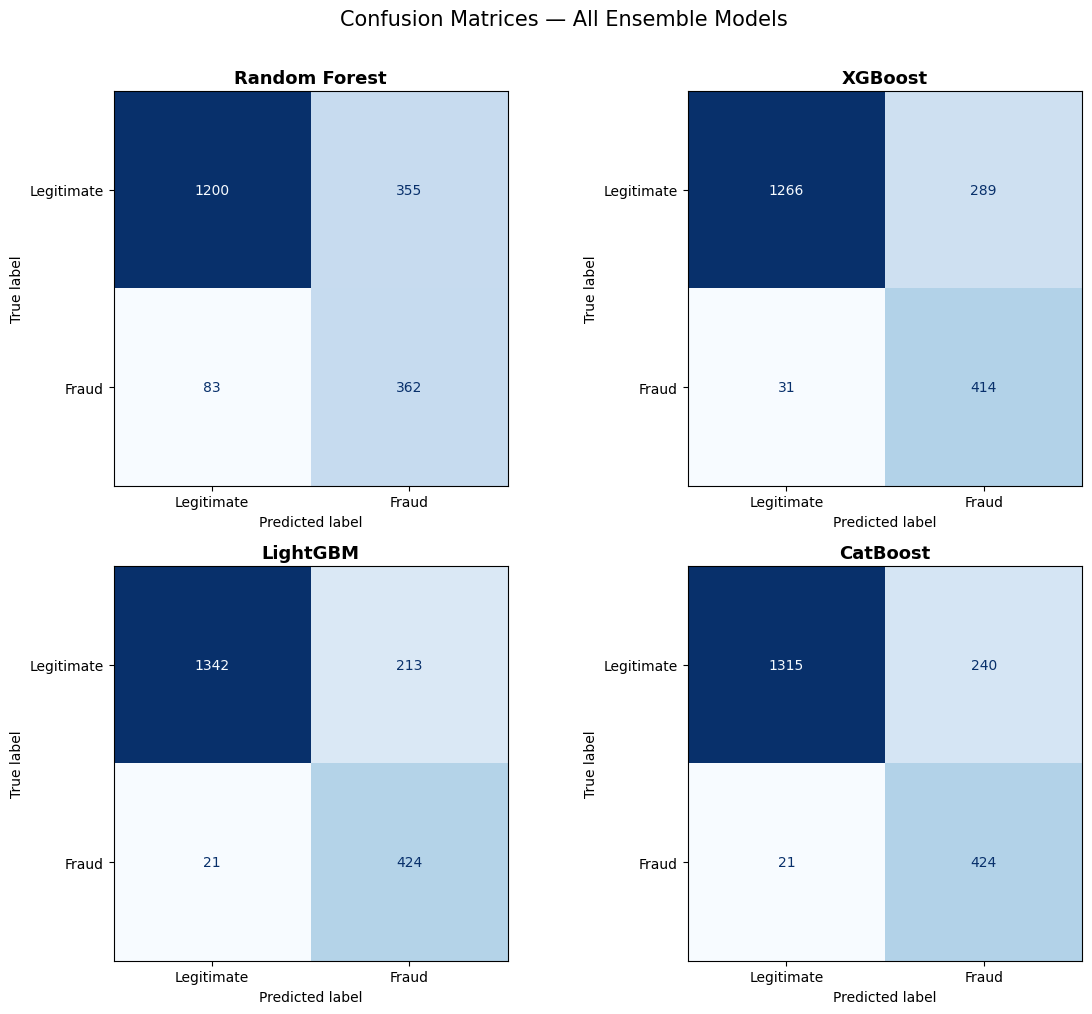

In [27]:
#HEAT MAPS CONFUSION MATRIX FOR EACH MODEL FOR CLEARER INSIGHTS

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
models_list = [
    ('Random Forest', y_pred_rf),
    ('XGBoost',       y_pred_xgb),
    ('LightGBM',      y_pred_lgbm),
    ('CatBoost',      y_pred_cb),
]

for ax, (name, y_pred) in zip(axes, models_list):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Legitimate', 'Fraud']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — All Ensemble Models', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

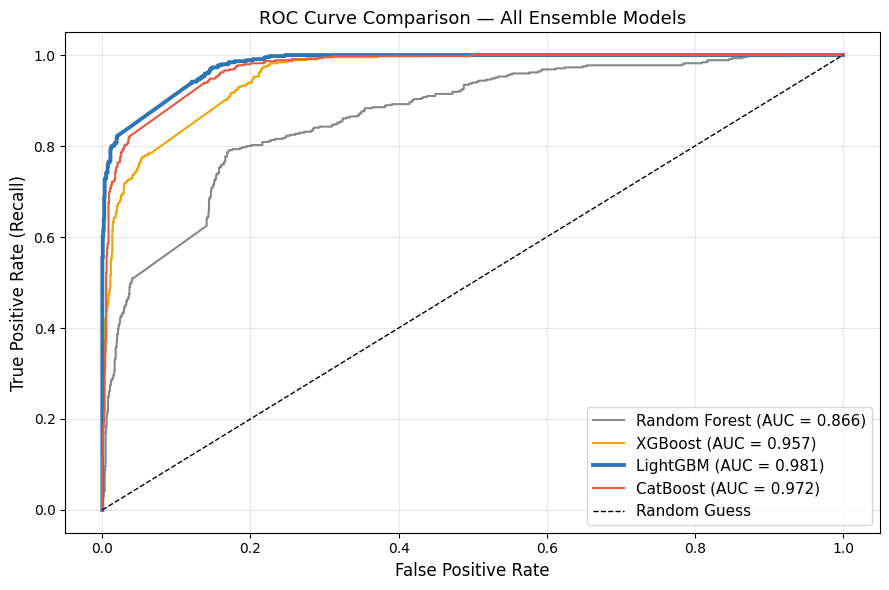

In [28]:
# Plot ROC curves for all four models

plt.figure(figsize=(9, 6))
colors = ['#888888', '#F0A500', '#2E75B6', '#E8593C']

for (name, (mdl, _)), col in zip(models_dict.items(), colors):
    y_prob = mdl.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    # Making LightGBM line thicker so it stands out as the best model
    lw = 2.8 if name == 'LightGBM' else 1.5
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=col, linewidth=lw)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve Comparison — All Ensemble Models', fontsize=13)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_models.png', dpi=150)
plt.show()

In [29]:
# 5-FOLD STRATIFIED CROSS-VALIDATION

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# We use a pipeline that applies SMOTE inside each fold 
cv_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=6,
        min_samples_leaf=10, max_features='sqrt', random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=4,
        min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric='logloss'
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=5,
        num_leaves=20, min_child_samples=20, random_state=42
    ),
    'CatBoost': CatBoostClassifier(
        iterations=100, learning_rate=0.1, depth=5,
        min_data_in_leaf=20, random_seed=42, verbose=0
    ),
}

# Run cross-validation for each model
cv_results = []

for name, mdl in cv_models.items():
    # Wrap model in a pipeline with SMOTE so oversampling happens
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', mdl)
    ])

    scores = cross_validate(
        pipeline, X, y,
        cv=cv,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
        n_jobs=-1
    )

    cv_results.append({
        'Model':     name,
        'CV Accuracy':  scores['test_accuracy'].mean(),
        'CV Precision': scores['test_precision'].mean(),
        'CV Recall':    scores['test_recall'].mean(),
        'CV F1':        scores['test_f1'].mean(),
        'CV ROC-AUC':   scores['test_roc_auc'].mean(),
        # Standard deviation tells us how stable the model is across folds
        'Recall Std':   scores['test_recall'].std(),
        'AUC Std':      scores['test_roc_auc'].std(),
    })

    print(f"{name} done — Avg Recall: {scores['test_recall'].mean():.4f} "
          f"± {scores['test_recall'].std():.4f}")

cv_df = pd.DataFrame(cv_results)
print("\n=== 5-FOLD CROSS-VALIDATION RESULTS ===")
print(cv_df.round(4).to_string(index=False))

Random Forest done — Avg Recall: 0.8516 ± 0.0097
XGBoost done — Avg Recall: 0.9213 ± 0.0075
LightGBM done — Avg Recall: 0.9546 ± 0.0071
CatBoost done — Avg Recall: 0.9492 ± 0.0111

=== 5-FOLD CROSS-VALIDATION RESULTS ===
        Model  CV Accuracy  CV Precision  CV Recall  CV F1  CV ROC-AUC  Recall Std  AUC Std
Random Forest       0.8142        0.5534     0.8516 0.6708      0.9060      0.0097   0.0056
      XGBoost       0.8515        0.6099     0.9213 0.7339      0.9610      0.0075   0.0030
     LightGBM       0.8882        0.6763     0.9546 0.7916      0.9808      0.0071   0.0017
     CatBoost       0.8808        0.6619     0.9492 0.7798      0.9760      0.0111   0.0022


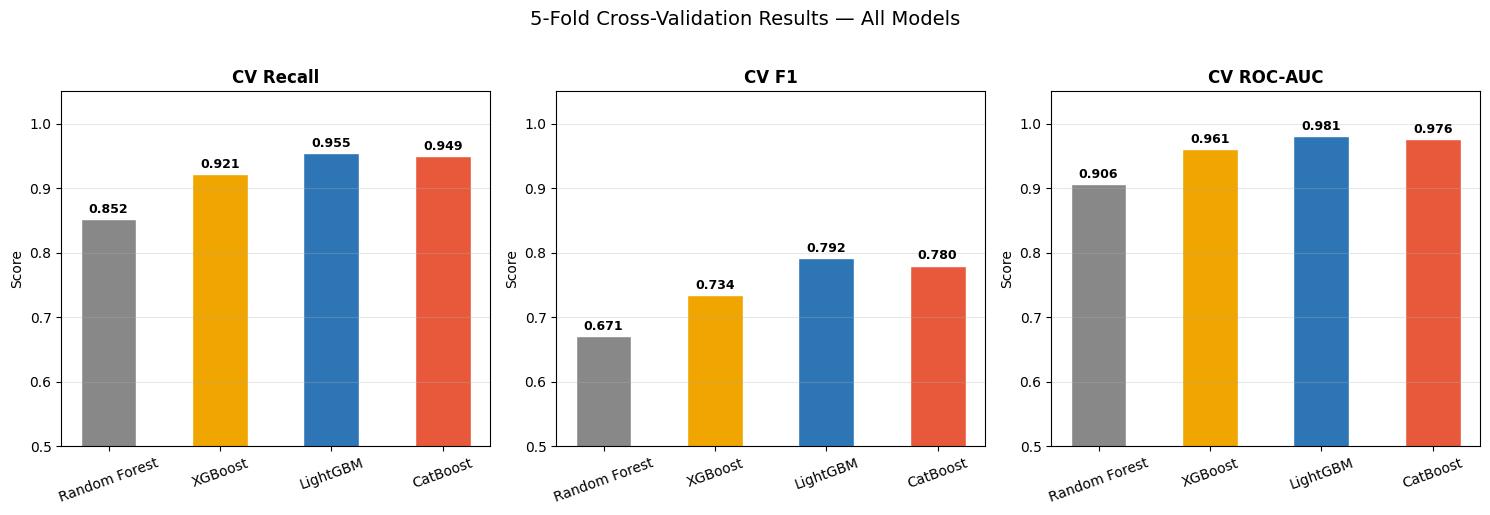

In [30]:
# Visualising cross-validation results 

metrics_to_plot = ['CV Recall', 'CV F1', 'CV ROC-AUC']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

bar_colors = ['#888888', '#F0A500', '#2E75B6', '#E8593C']

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(
        cv_df['Model'],
        cv_df[metric],
        color=bar_colors,
        edgecolor='white',
        width=0.5
    )
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0.5, 1.05)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)

    # Add score labels on top of each bar
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

plt.suptitle('5-Fold Cross-Validation Results — All Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('cross_validation_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# SELECT BEST MODEL

best_model      = lgbm_model
best_model_name = "LightGBM"

print(f"Best model: {best_model_name}")
print(f"Test Recall:   {recall_score(y_test, y_pred_lgbm):.4f}")
print(f"Test F1:       {f1_score(y_test, y_pred_lgbm):.4f}")
print(f"Test ROC-AUC:  {roc_auc_score(y_test, lgbm_model.predict_proba(X_test)[:,1]):.4f}")

Best model: LightGBM
Test Recall:   0.9528
Test F1:       0.7837
Test ROC-AUC:  0.9805


SHAP values shape: (2000, 142)


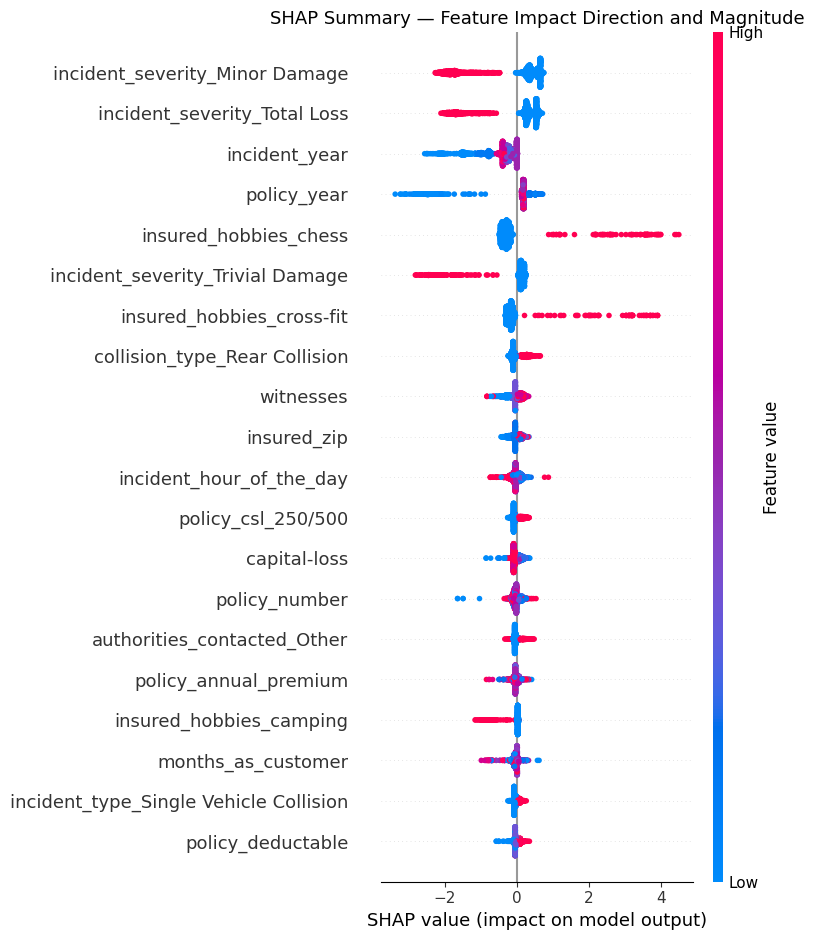

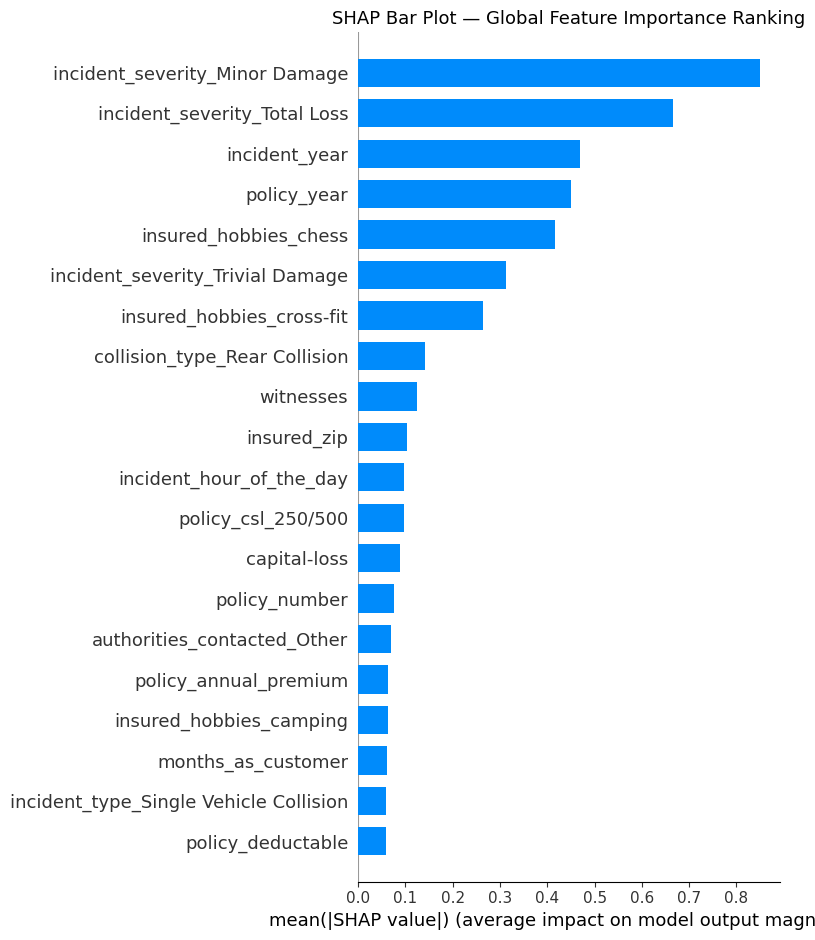


Top 10 most important features (SHAP):
                         Feature  SHAP_Importance
  incident_severity_Minor Damage         0.849617
    incident_severity_Total Loss         0.665392
                   incident_year         0.468363
                     policy_year         0.449932
           insured_hobbies_chess         0.417263
incident_severity_Trivial Damage         0.313308
       insured_hobbies_cross-fit         0.264539
   collision_type_Rear Collision         0.141503
                       witnesses         0.124085
                     insured_zip         0.104302


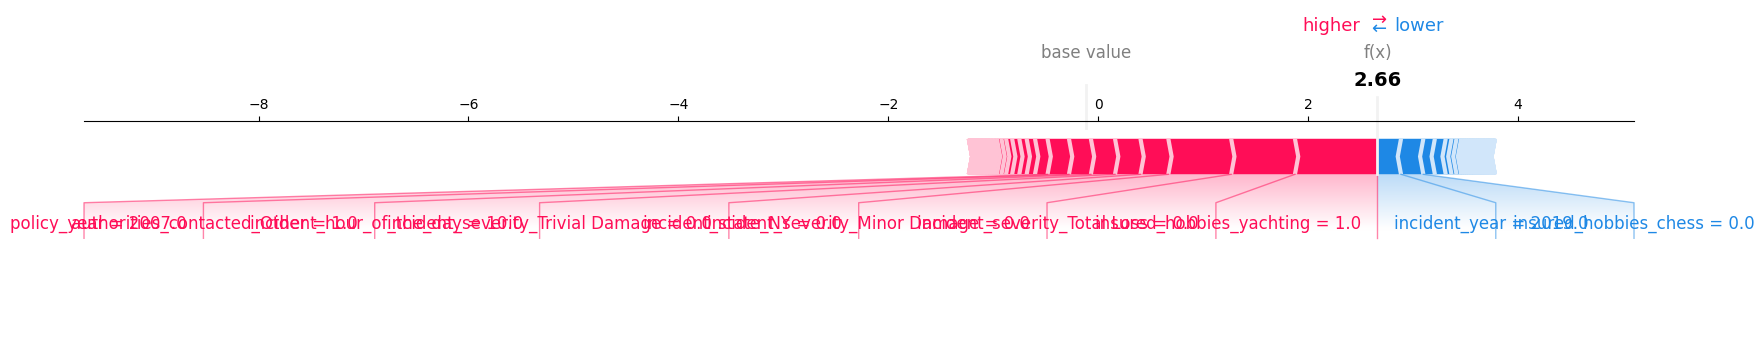

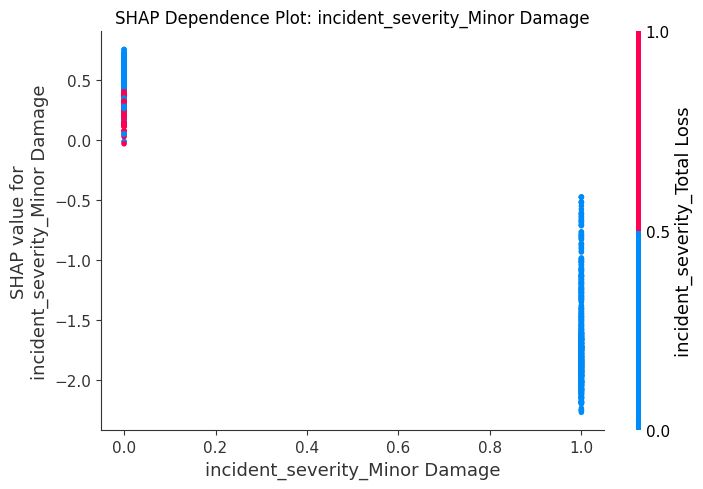

In [32]:
#SHAP GLOBAL EXPLAINABILITY

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)

# PLOT1:Dot summary plot 
# Each dot is one claim. Red = high feature value, Blue = low.
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False, max_display=20)
plt.title('SHAP Summary — Feature Impact Direction and Magnitude', fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary_dot.png', dpi=150, bbox_inches='tight')
plt.show()

# PLOT2:Bar plot ──
# Mean absolute SHAP value = overall feature importance ranking
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=20)
plt.title('SHAP Bar Plot — Global Feature Importance Ranking', fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Extract top 10 SHAP features
shap_importance = pd.DataFrame({
    'Feature':         X_test.columns,
    'SHAP_Importance': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_Importance', ascending=False)

print("\nTop 10 most important features (SHAP):")
print(shap_importance.head(10).to_string(index=False))

# PLOT 3: Force plot for one fraud case 
# This explains a SINGLE prediction and shows which features pushed it to fraud
fraud_indices   = (y_test == 1).values
first_fraud_idx = fraud_indices.argmax()

shap.force_plot(
    explainer.expected_value,
    shap_values[first_fraud_idx],
    X_test.iloc[first_fraud_idx],
    matplotlib=True,
    show=False
)
plt.savefig('shap_force_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# PLOT 4: Dependence plot for top feature
# Shows HOW the top feature's value changes the model's output
top_feature = shap_importance.iloc[0]['Feature']
shap.dependence_plot(top_feature, shap_values, X_test, show=False)
plt.title(f'SHAP Dependence Plot: {top_feature}', fontsize=12)
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150)
plt.show()

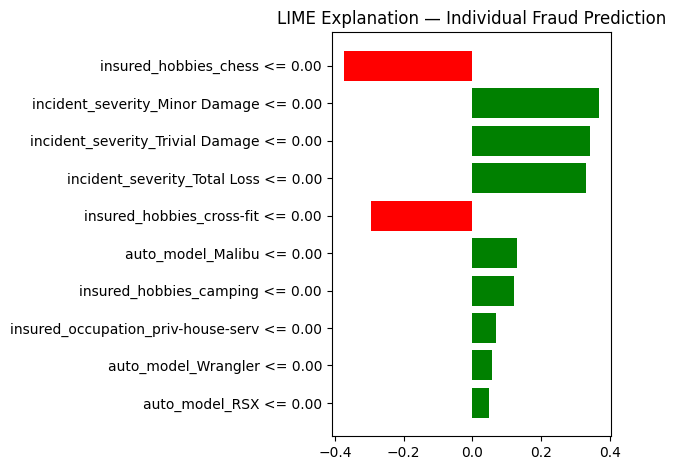

LIME feature weights for this specific claim:
  → LEGIT  -0.3721  |  insured_hobbies_chess <= 0.00
  → FRAUD  +0.3667  |  incident_severity_Minor Damage <= 0.00
  → FRAUD  +0.3408  |  incident_severity_Trivial Damage <= 0.00
  → FRAUD  +0.3298  |  incident_severity_Total Loss <= 0.00
  → LEGIT  -0.2939  |  insured_hobbies_cross-fit <= 0.00
  → FRAUD  +0.1291  |  auto_model_Malibu <= 0.00
  → FRAUD  +0.1207  |  insured_hobbies_camping <= 0.00
  → FRAUD  +0.0680  |  insured_occupation_priv-house-serv <= 0.00
  → FRAUD  +0.0567  |  auto_model_Wrangler <= 0.00
  → FRAUD  +0.0475  |  auto_model_RSX <= 0.00


In [33]:
# LIME LOCAL EXPLAINABILITY
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_smote.values,
    feature_names=X_test.columns.tolist(),
    class_names=['Legitimate', 'Fraud'],
    mode='classification',
    random_state=42
)

lime_exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[first_fraud_idx].values,
    predict_fn=best_model.predict_proba,
    num_features=10
)

lime_exp.as_pyplot_figure()
plt.title('LIME Explanation — Individual Fraud Prediction', fontsize=12)
plt.tight_layout()
plt.savefig('lime_explanation.png', dpi=150)
plt.show()


print("LIME feature weights for this specific claim:")
for feat, weight in lime_exp.as_list():
    direction = "→ FRAUD" if weight > 0 else "→ LEGIT"
    print(f"  {direction}  {weight:+.4f}  |  {feat}")

In [34]:
# FORMAL CONSISTENCY SCORING — Jaccard Similarity & Spearman Rank Correlation

from scipy.stats import spearmanr

# SHAP top 10 features in ranked order (rank 1 = most important)
shap_top10_ranked = [
    'incident_severity_Minor Damage',    # rank 1
    'incident_severity_Total Loss',      # rank 2
    'incident_year',                     # rank 3
    'policy_year',                       # rank 4
    'insured_hobbies_chess',             # rank 5
    'incident_severity_Trivial Damage',  # rank 6
    'insured_hobbies_cross-fit',         # rank 7
    'collision_type_Rear Collision',     # rank 8
    'witnesses',                         # rank 9
    'insured_zip'                        # rank 10
]

# LIME top 10 features in ranked order (rank 1 = most important)
lime_top10_ranked = [
    'insured_hobbies_chess',             # rank 1
    'incident_severity_Minor Damage',    # rank 2
    'incident_severity_Trivial Damage',  # rank 3
    'incident_severity_Total Loss',      # rank 4
    'insured_hobbies_cross-fit',         # rank 5
    'auto_model_Malibu',                 # rank 6
    'insured_hobbies_camping',           # rank 7
    'insured_occupation_priv-house-serv',# rank 8
    'auto_model_Wrangler',               # rank 9
    'auto_model_RSX'                     # rank 10
]

# JACCARD SIMILARITY 
shap_set = set(shap_top10_ranked)
lime_set = set(lime_top10_ranked)

intersection = shap_set & lime_set
union = shap_set | lime_set
jaccard = len(intersection) / len(union)

print(f"Overlapping features: {len(intersection)}")
print(f"Total unique features across both: {len(union)}")
print(f"Jaccard Similarity: {jaccard:.4f}")

# SPEARMAN RANK CORRELATION
# Only on the 5 shared features
shared_features = list(intersection)

shap_ranks = [shap_top10_ranked.index(f) + 1 for f in shared_features]
lime_ranks  = [lime_top10_ranked.index(f) + 1 for f in shared_features]

correlation, pvalue = spearmanr(shap_ranks, lime_ranks)

print(f"\nShared features used for Spearman: {len(shared_features)}")
print(f"Spearman Rank Correlation: {correlation:.4f}")
print(f"P-value: {pvalue:.4f}")

if pvalue < 0.05:
    print("Result is statistically significant (p < 0.05)")
else:
    print("Result is not statistically significant (p >= 0.05)")

Overlapping features: 5
Total unique features across both: 15
Jaccard Similarity: 0.3333

Shared features used for Spearman: 5
Spearman Rank Correlation: 0.5000
P-value: 0.3910
Result is not statistically significant (p >= 0.05)


In [35]:
# SHAP AND LIME COMPARISION
shap_top10 = set(shap_importance.head(10)['Feature'].str.lower())

lime_df = pd.DataFrame(lime_exp.as_list(), columns=['Feature_condition', 'LIME_Weight'])
lime_df['Feature_clean']   = lime_df['Feature_condition'].str.split(' <=').str[0]
lime_df['LIME_AbsWeight']  = lime_df['LIME_Weight'].abs()
lime_df = lime_df.sort_values('LIME_AbsWeight', ascending=False)

lime_top10 = set(lime_df['Feature_clean'].str.lower())

# Features that appear in BOTH methods
common_features = shap_top10.intersection(lime_top10)

print(f"Features in SHAP top 10:   {len(shap_top10)}")
print(f"Features in LIME top 10:   {len(lime_top10)}")
print(f"Features in BOTH methods:  {len(common_features)}")
print(f"\nOverlapping features:")
for f in sorted(common_features):
    print(f"  ✓ {f}")

print("\n--- SHAP Global Top 10 ---")
print(shap_importance.head(10)[['Feature','SHAP_Importance']].to_string(index=False))

print("\n--- LIME Local Top 10 (this one claim) ---")
print(lime_df[['Feature_clean','LIME_AbsWeight']].to_string(index=False))

Features in SHAP top 10:   10
Features in LIME top 10:   10
Features in BOTH methods:  5

Overlapping features:
  ✓ incident_severity_minor damage
  ✓ incident_severity_total loss
  ✓ incident_severity_trivial damage
  ✓ insured_hobbies_chess
  ✓ insured_hobbies_cross-fit

--- SHAP Global Top 10 ---
                         Feature  SHAP_Importance
  incident_severity_Minor Damage         0.849617
    incident_severity_Total Loss         0.665392
                   incident_year         0.468363
                     policy_year         0.449932
           insured_hobbies_chess         0.417263
incident_severity_Trivial Damage         0.313308
       insured_hobbies_cross-fit         0.264539
   collision_type_Rear Collision         0.141503
                       witnesses         0.124085
                     insured_zip         0.104302

--- LIME Local Top 10 (this one claim) ---
                     Feature_clean  LIME_AbsWeight
             insured_hobbies_chess        0.372139
   

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1778, number of negative: 6222
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003775 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2502
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 142
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.222250 -> initscore=-1.252602
[LightGBM] [Info] Start training from score -1.252602
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

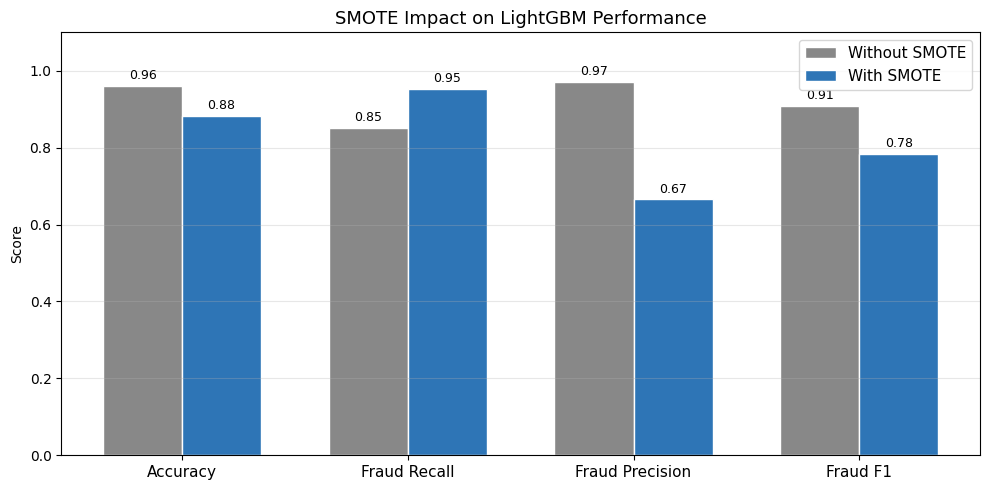

In [36]:
#SMOTE IMPACT ANALYSIS

lgbm_no_smote = LGBMClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=5,
    num_leaves=20, min_child_samples=20, random_state=42
)
lgbm_no_smote.fit(X_train, y_train)  # original imbalanced data
y_pred_no_smote = lgbm_no_smote.predict(X_test)

print("===== WITHOUT SMOTE =====")
print(classification_report(y_test, y_pred_no_smote, target_names=['Legitimate','Fraud']))

print("===== WITH SMOTE =====")
print(classification_report(y_test, y_pred_lgbm, target_names=['Legitimate','Fraud']))

# bar chart
metrics   = ['Accuracy', 'Fraud Recall', 'Fraud Precision', 'Fraud F1']
no_smote  = [
    accuracy_score(y_test, y_pred_no_smote),
    recall_score(y_test, y_pred_no_smote),
    precision_score(y_test, y_pred_no_smote),
    f1_score(y_test, y_pred_no_smote)
]
with_smote = [
    accuracy_score(y_test, y_pred_lgbm),
    recall_score(y_test, y_pred_lgbm),
    precision_score(y_test, y_pred_lgbm),
    f1_score(y_test, y_pred_lgbm)
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, no_smote,  width, label='Without SMOTE', color='#888888', edgecolor='white')
bars2 = ax.bar(x + width/2, with_smote, width, label='With SMOTE',    color='#2E75B6', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('SMOTE Impact on LightGBM Performance', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('smote_impact.png', dpi=150)
plt.show()

In [37]:
# SAVING THE BEST MODEL AND FEATURES
joblib.dump(best_model, 'fraud_lgbm_model.pkl')
joblib.dump(X_train_smote.columns.tolist(), 'model_features.pkl')

print("Model saved:    fraud_lgbm_model.pkl")
print("Features saved: model_features.pkl")
print(f"Total features: {len(X_train_smote.columns)}")

Model saved:    fraud_lgbm_model.pkl
Features saved: model_features.pkl
Total features: 142


In [38]:
import pickle

with open("fraud_lgbm_model.pkl", "wb") as f:
    pickle.dump(lgbm_model, f)

with open("model_features.pkl", "wb") as f:
    pickle.dump(X_train.columns.tolist(), f)

print("Saved successfully!")

Saved successfully!


In [39]:
df_use['fraud_reported_label'] = df_use['fraud_reported'].map({1: 'Fraud', 0: 'Legitimate'})
df_use.to_csv("insurance_claims_cleaned.csv", index=False)
print("Exported:", df_use.shape)

Exported: (10000, 37)


In [40]:
import os
print(os.getcwd())

C:\Users\PEACH
